# Robust linear regression: which observation model should we use?

A straight line can be trained with several probability models. The model determines how a residual
$r_i=y_i-\hat y_i$ is penalized:

- **Gaussian noise** $\Rightarrow$ squared error (MSE),
- **Laplace noise** $\Rightarrow$ absolute error (MAE),
- **Student-t noise** $\Rightarrow$ a heavy-tailed robust loss.

We will fit the **same data** with all three and watch two outliers change the answer.

In [1]:
import math
import torch
import torch.distributions as D
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
torch.set_default_dtype(torch.float64)
_ = torch.manual_seed(7)

In [2]:
INK = "#17343b"
MUTED = "#72858a"
ORANGE = "#ef7d00"
BLUE = "#2f6fbb"
TEAL = "#238b8e"
GREEN = "#20a647"
RED = "#d9485f"

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
    "legend.frameon": False,
    "lines.linewidth": 2.3,
})

## 1. Make one simple regression dataset

The underlying relationship is $y=1+2x$. Most observations have small Gaussian noise. We then replace
two measurements by obvious recording errors.

In [3]:
x = torch.linspace(-2.0, 2.0, 25)
true_intercept = torch.tensor(1.0)
true_slope = torch.tensor(2.0)
noise_scale = torch.tensor(0.35)

y_mean = true_intercept + true_slope * x
y_clean = y_mean + D.Normal(0.0, noise_scale).sample((x.numel(),))

In [4]:
outlier_index = torch.tensor([4, 20])
y = y_clean.clone()
y[outlier_index] += torch.tensor([5.0, -5.0])

print("true parameters: intercept = 1, slope = 2")
print("outlier indices:", outlier_index.tolist())

true parameters: intercept = 1, slope = 2
outlier indices: [4, 20]


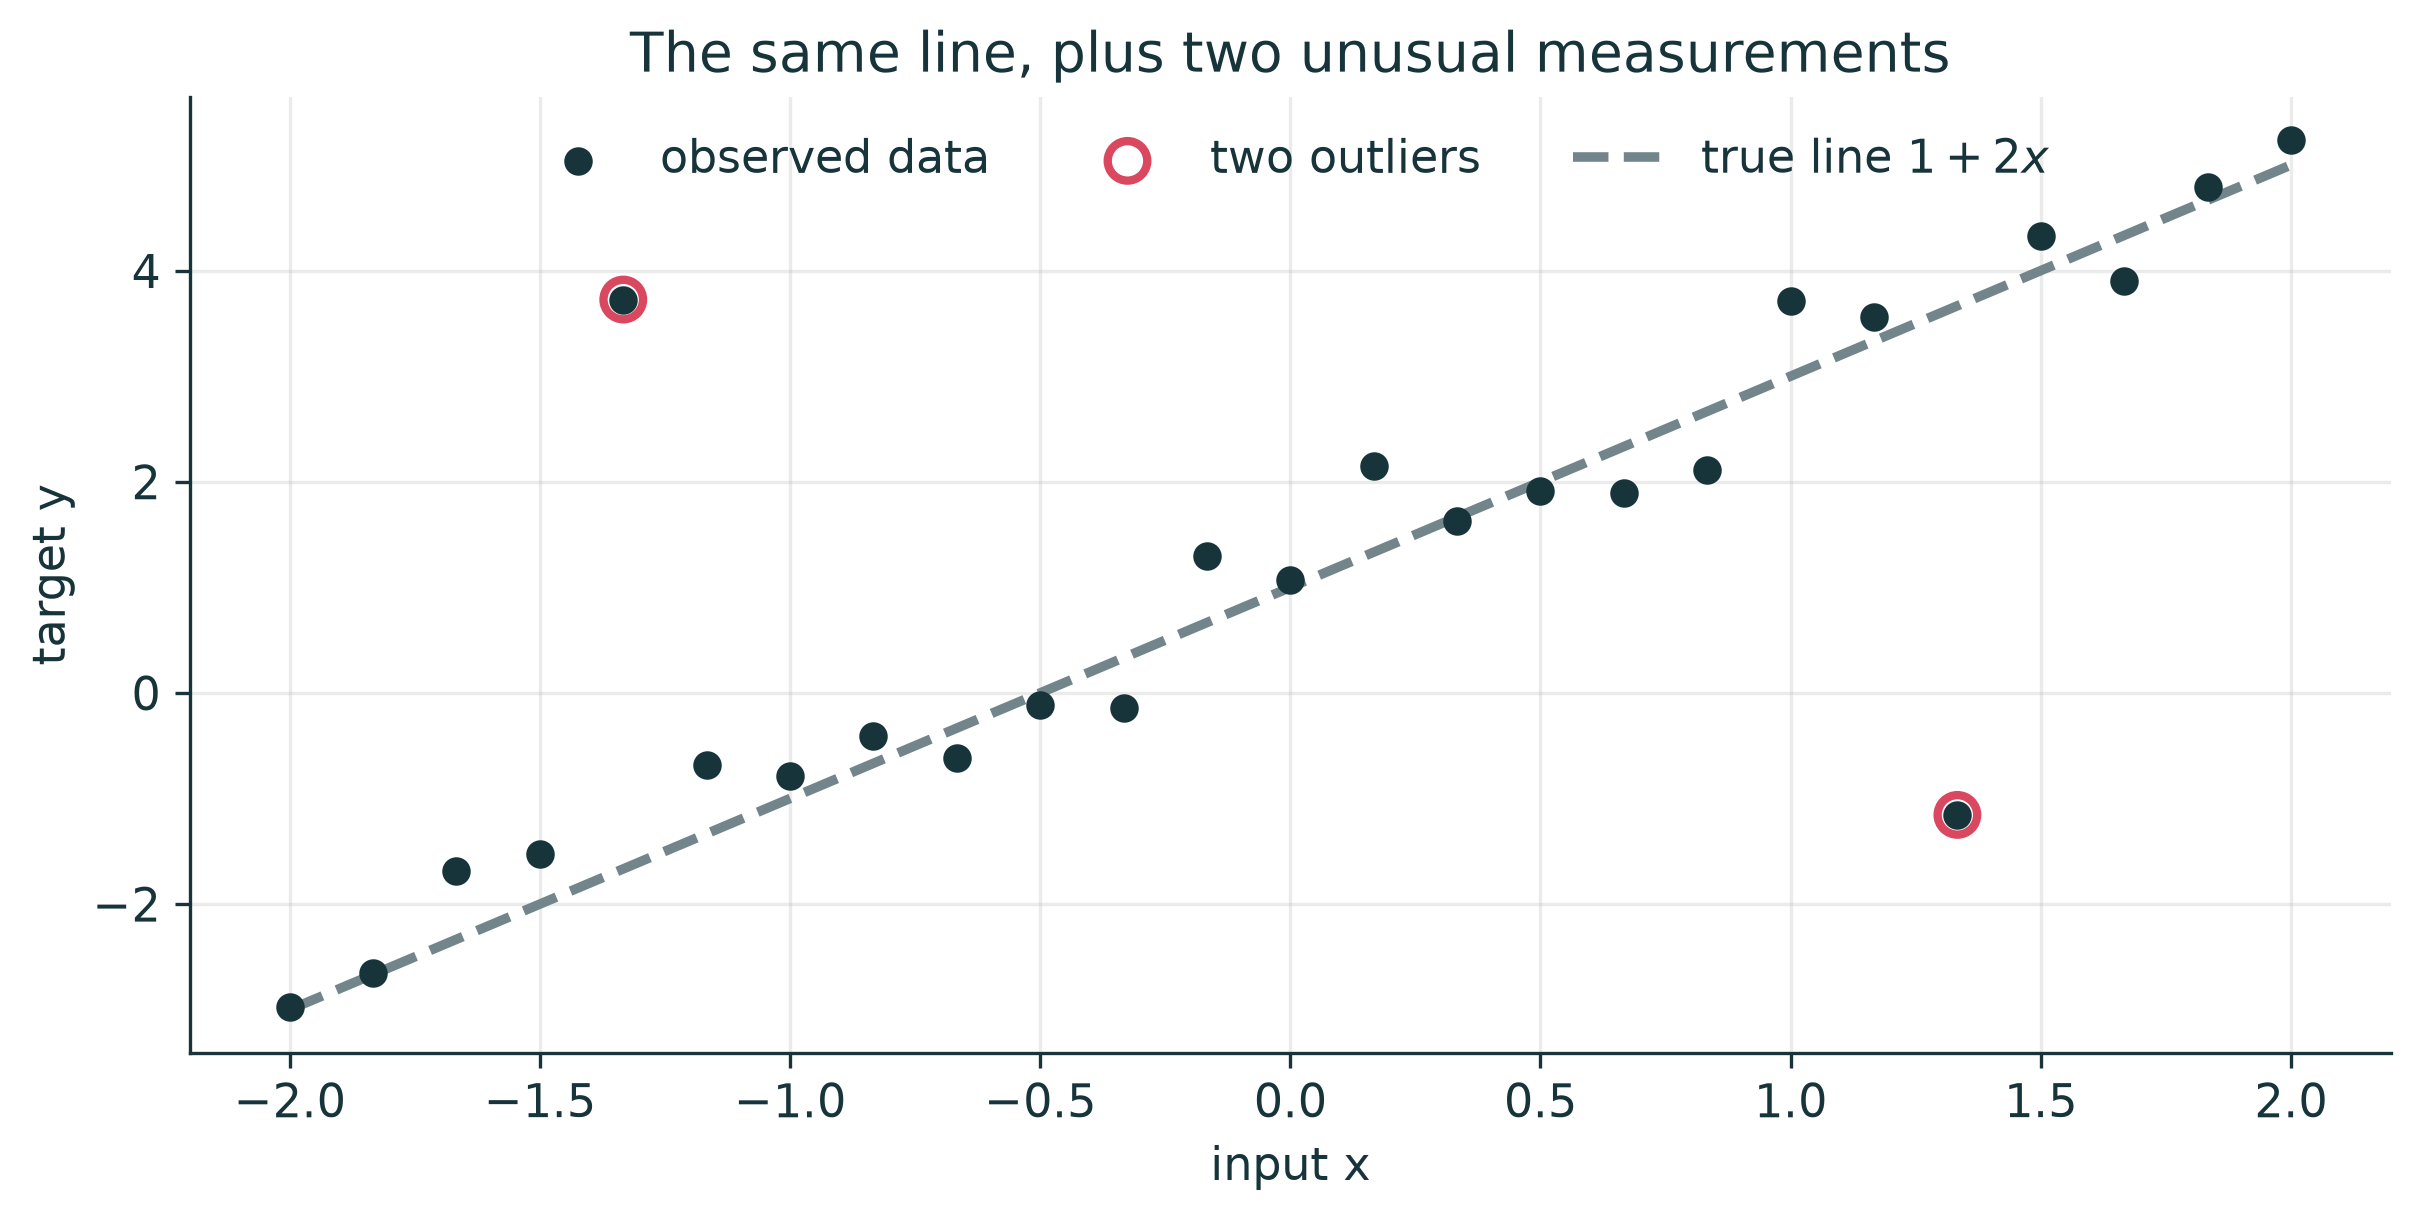

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.scatter(x, y, s=34, color=INK, label="observed data", zorder=3)
ax.scatter(x[outlier_index], y[outlier_index], s=90, facecolor="none",
           edgecolor=RED, linewidth=2, label="two outliers", zorder=4)
ax.plot(x, y_mean, color=MUTED, linestyle="--", label=r"true line $1+2x$")
ax.set(xlabel="input x", ylabel="target y", title="The same line, plus two unusual measurements")
ax.grid(alpha=0.25)
ax.legend(ncols=3, loc="upper center")
plt.tight_layout()
plt.show()

## 2. Ask what residuals each model considers plausible

A residual is $r=y-\hat y$. Every model puts its highest density near $r=0$, but their tails differ.
A heavy-tailed model leaves appreciable density far from zero, so an unusual measurement is possible
without forcing the fitted line to chase it.

In [6]:
residual = torch.linspace(-6.0, 6.0, 1201)
zero = torch.tensor(0.0)

residual_models = {
    "Gaussian → MSE": (D.Normal(zero, 1.0), BLUE),
    "Laplace → MAE": (D.Laplace(zero, 1.0), ORANGE),
    "Student-t (df=3)": (D.StudentT(3.0, zero, 1.0), TEAL),
}

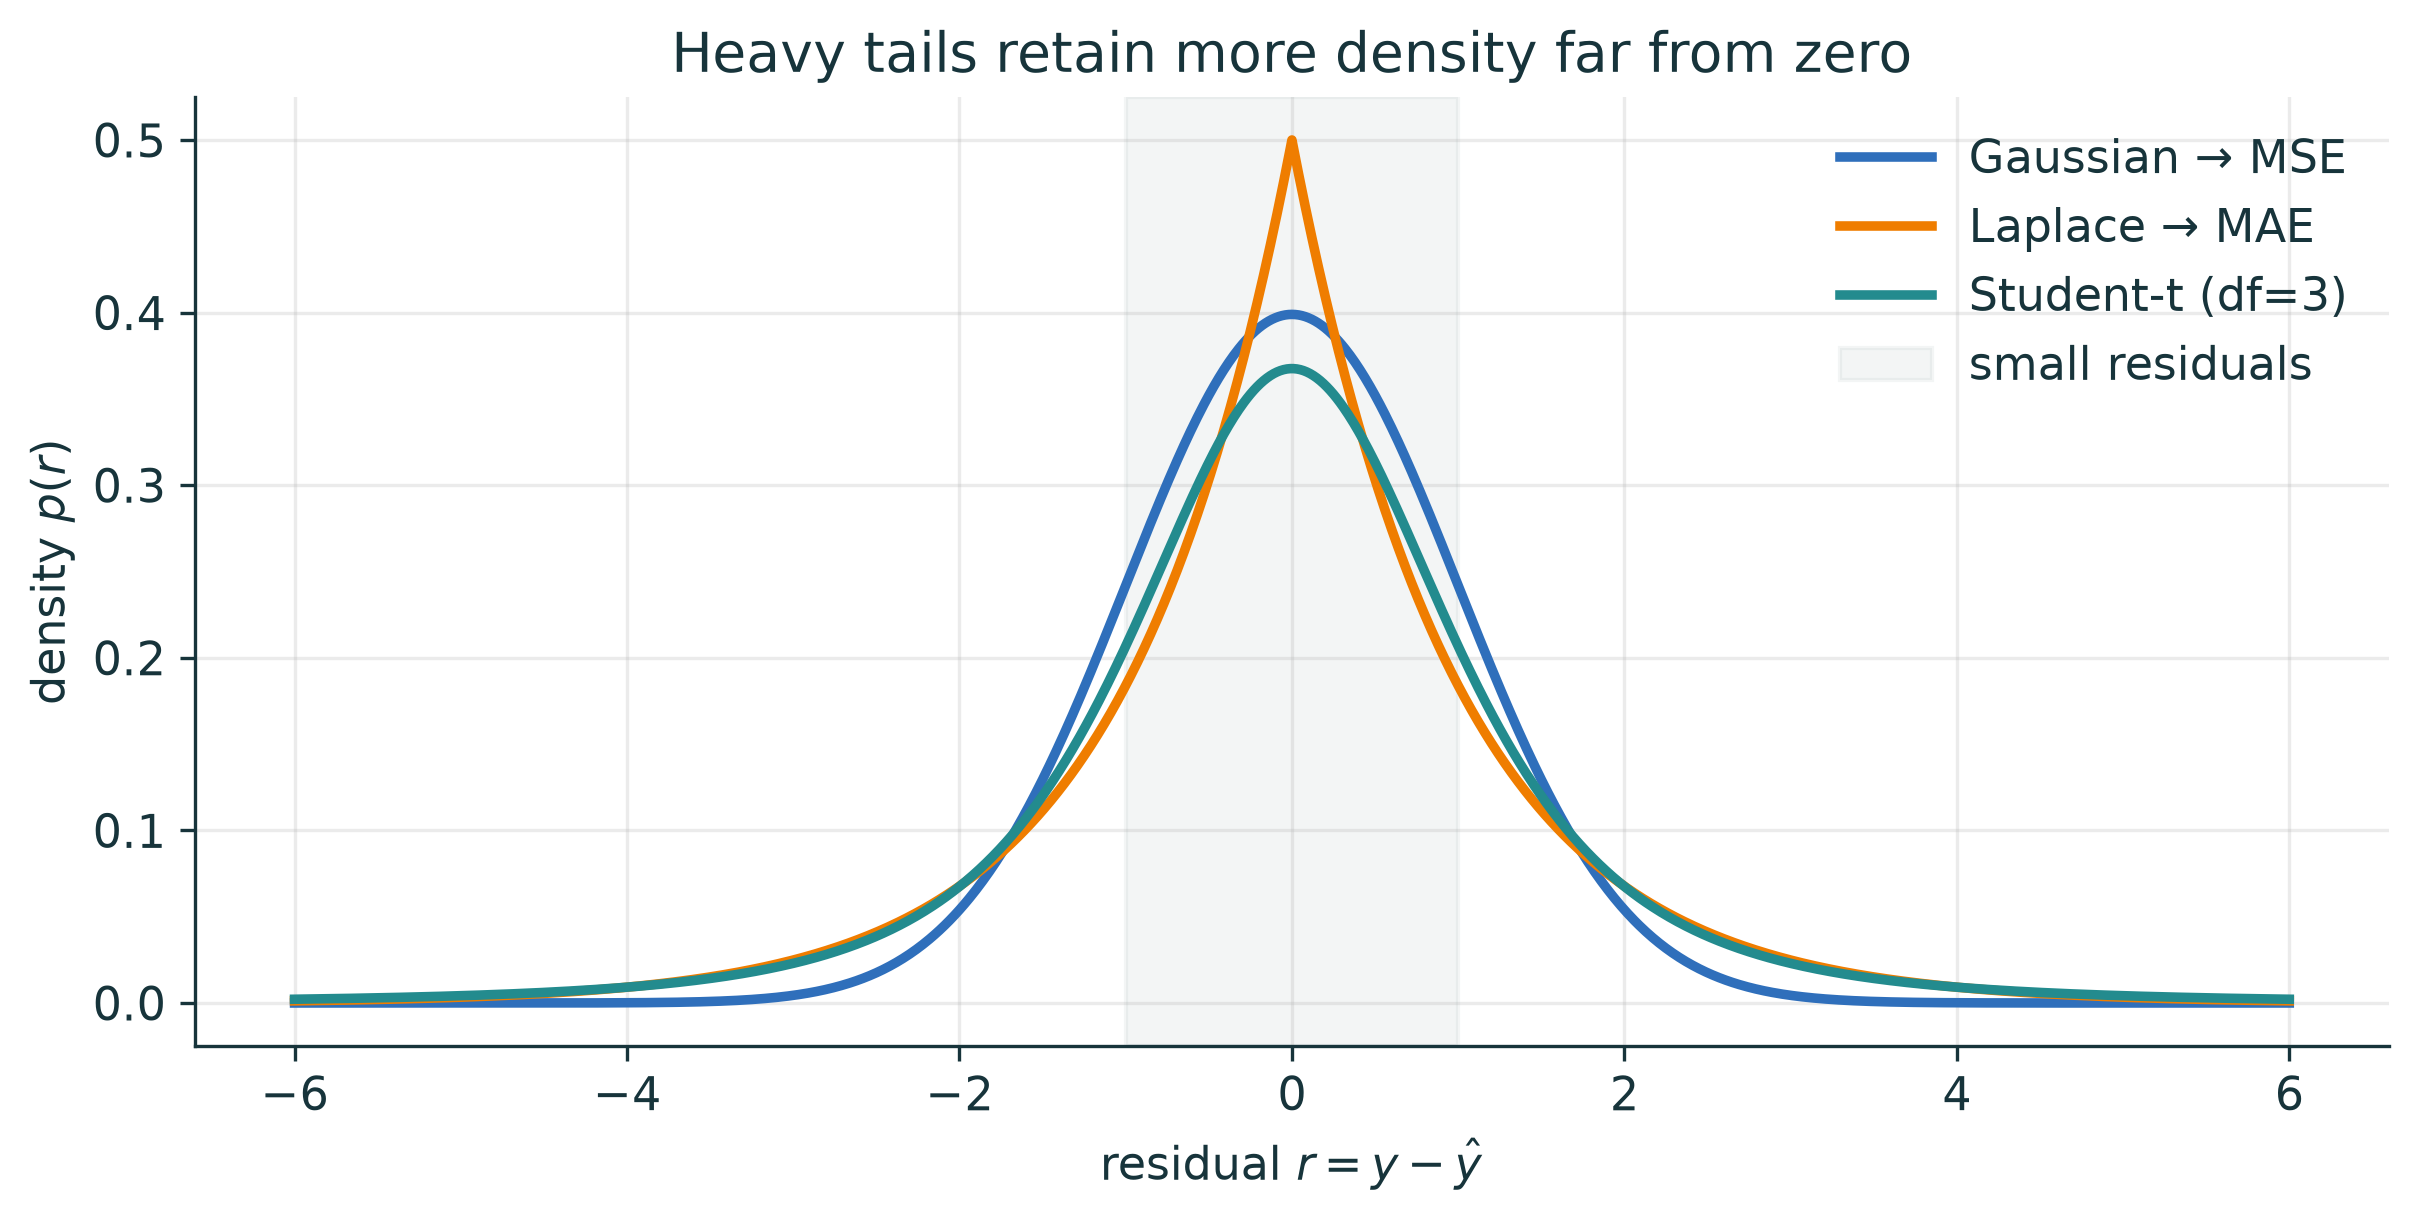

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for name, (distribution, color) in residual_models.items():
    ax.plot(residual, distribution.log_prob(residual).exp(), color=color, label=name)

ax.set(xlabel=r"residual $r=y-\hat y$", ylabel=r"density $p(r)$",
       title="Heavy tails retain more density far from zero")
ax.axvspan(-1, 1, color=MUTED, alpha=0.08, label="small residuals")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
far_residual = torch.tensor(4.0)
for name, (distribution, _) in residual_models.items():
    density = distribution.log_prob(far_residual).exp()
    print(f"{name:18s}: p(r=4) = {density:.6f}")

Gaussian → MSE    : p(r=4) = 0.000134
Laplace → MAE     : p(r=4) = 0.009158
Student-t (df=3)  : p(r=4) = 0.009163


At $r=4$, Laplace and Student-t assign roughly **68 times** the density assigned by a standard Gaussian.
This does not make the point *good*; it makes the point less astonishing under the assumed noise process.

## 3. Convert density into a training loss

Maximum likelihood minimizes $-\log p(r)$. Therefore **more tail density means a smaller penalty** for a
large residual. Fix the scale at $s=1$ below and subtract the loss at $r=0$, so only the shape remains.

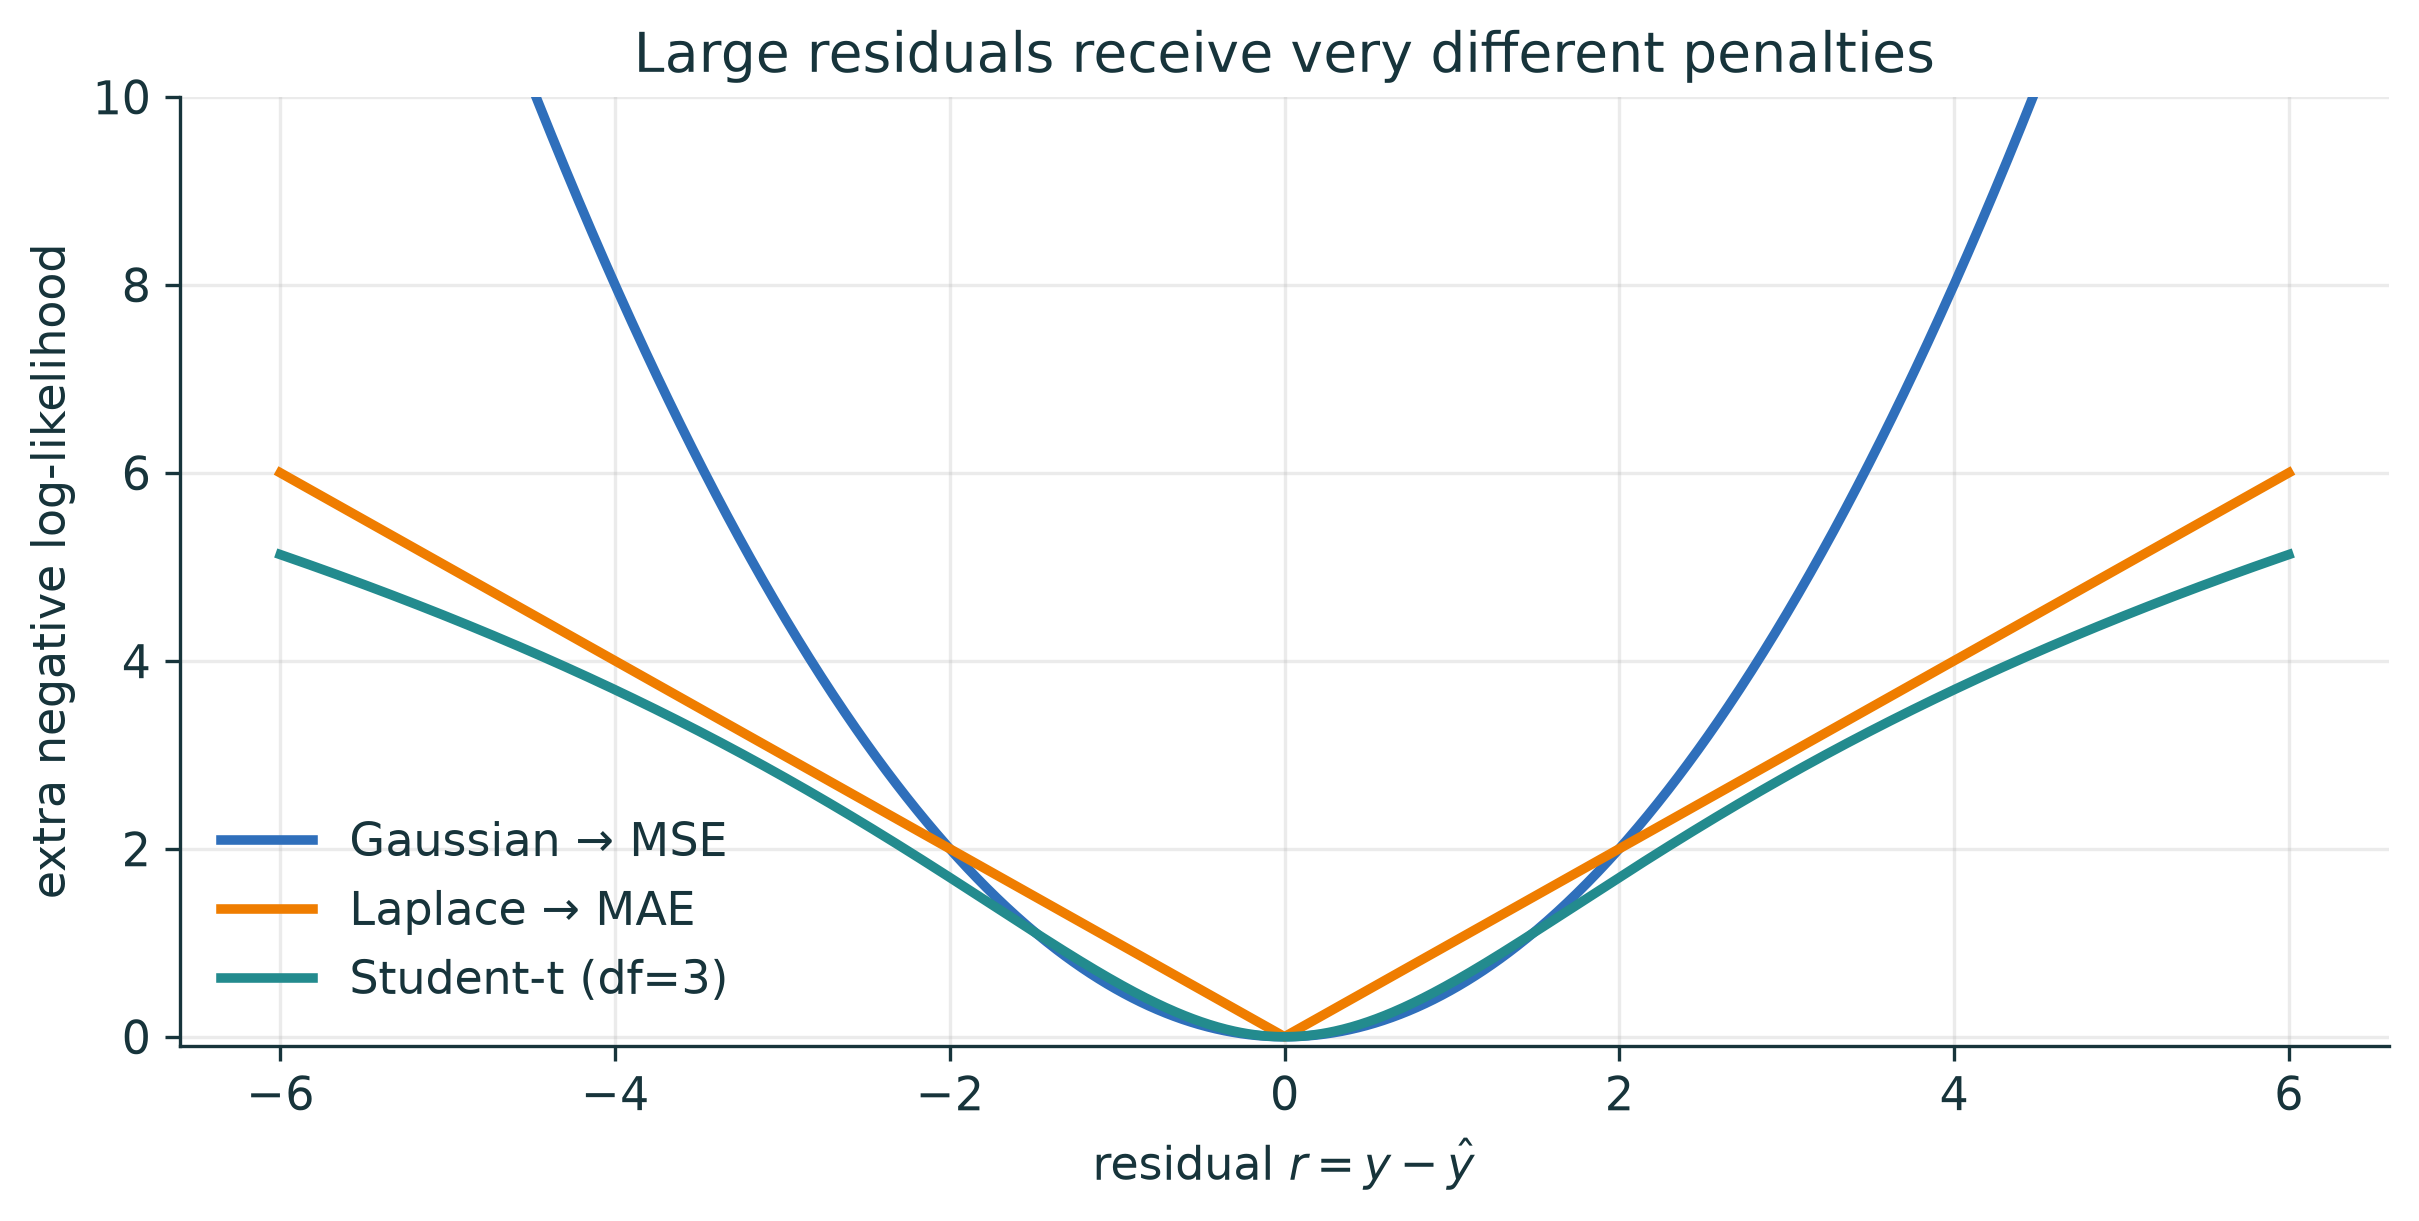

In [9]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for name, (distribution, color) in residual_models.items():
    loss = -distribution.log_prob(residual)
    loss -= -distribution.log_prob(zero)
    ax.plot(residual, loss, color=color, label=name)

ax.set(xlabel=r"residual $r=y-\hat y$", ylabel="extra negative log-likelihood",
       title="Large residuals receive very different penalties", ylim=(-0.1, 10))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

For fixed scale, constants do not affect the best-fitting line:

$$
-\log \mathcal N(y\mid\mu,s^2)=\frac{(y-\mu)^2}{2s^2}+C
\quad\Longrightarrow\quad \text{MSE},
$$

$$
-\log \operatorname{Laplace}(y\mid\mu,b)=\frac{|y-\mu|}{b}+C
\quad\Longrightarrow\quad \text{MAE}.
$$

Student-t grows only logarithmically for very large residuals, so one extreme point cannot dominate the
whole fit as easily.

The optimizer responds to the *slope* of these losses:

- Gaussian: doubling a large residual roughly quadruples its extra loss, and its pull keeps growing.
- Laplace: doubling a residual doubles its extra loss, so its pull is capped at a constant magnitude.
- Student-t: the pull eventually decreases as a residual becomes extreme.

That is the practical meaning of robustness here: an outlier is retained in the dataset, but it cannot
dominate the update merely because it is far from the current line.

In [10]:
r = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
normal_extra = -D.Normal(0.0, 1.0).log_prob(r) + D.Normal(0.0, 1.0).log_prob(torch.tensor(0.0))
laplace_extra = -D.Laplace(0.0, 1.0).log_prob(r) + D.Laplace(0.0, 1.0).log_prob(torch.tensor(0.0))

print("Gaussian extra NLL:", normal_extra.tolist())
print("0.5 × residual²:   ", (0.5 * r.square()).tolist())
print("Laplace extra NLL:", laplace_extra.tolist())
print("absolute residual:", r.abs().tolist())

Gaussian extra NLL: [2.0, 0.125, 0.0, 0.125, 2.0]
0.5 × residual²:    [2.0, 0.125, 0.0, 0.125, 2.0]
Laplace extra NLL: [2.0, 0.5000000000000001, 0.0, 0.5000000000000001, 2.0]
absolute residual: [2.0, 0.5, 0.0, 0.5, 2.0]


## 4. Fit the same line three times

The prediction rule is always $\mu_i=b+wx_i$. Only the observation distribution—and therefore the
negative log-likelihood—changes.

In [11]:
fit_scale = torch.tensor(0.35)

def observation_model(name, mean):
    if name == "Gaussian":
        return D.Normal(mean, fit_scale)
    if name == "Laplace":
        return D.Laplace(mean, fit_scale)
    if name == "Student-t":
        return D.StudentT(3.0, mean, fit_scale)
    raise ValueError(name)

In [12]:
def fit_line(model_name, target, steps=1200):
    theta = torch.zeros(2, requires_grad=True)  # [intercept, slope]
    optimizer = torch.optim.Adam([theta], lr=0.035)

    for _ in range(steps):
        mean = theta[0] + theta[1] * x
        loss = -observation_model(model_name, mean).log_prob(target).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return theta.detach(), loss.detach()

In [13]:
fits = {}
for model_name in ["Gaussian", "Laplace", "Student-t"]:
    theta_hat, final_nll = fit_line(model_name, y)
    fits[model_name] = theta_hat
    print(f"{model_name:9s}: intercept={theta_hat[0]: .3f}, "
          f"slope={theta_hat[1]: .3f}, summed NLL={final_nll: .2f}")

Gaussian : intercept= 1.143, slope= 1.568, summed NLL= 197.06
Laplace  : intercept= 1.181, slope= 1.965, summed NLL= 41.57


Student-t: intercept= 1.130, slope= 1.946, summed NLL= 29.90


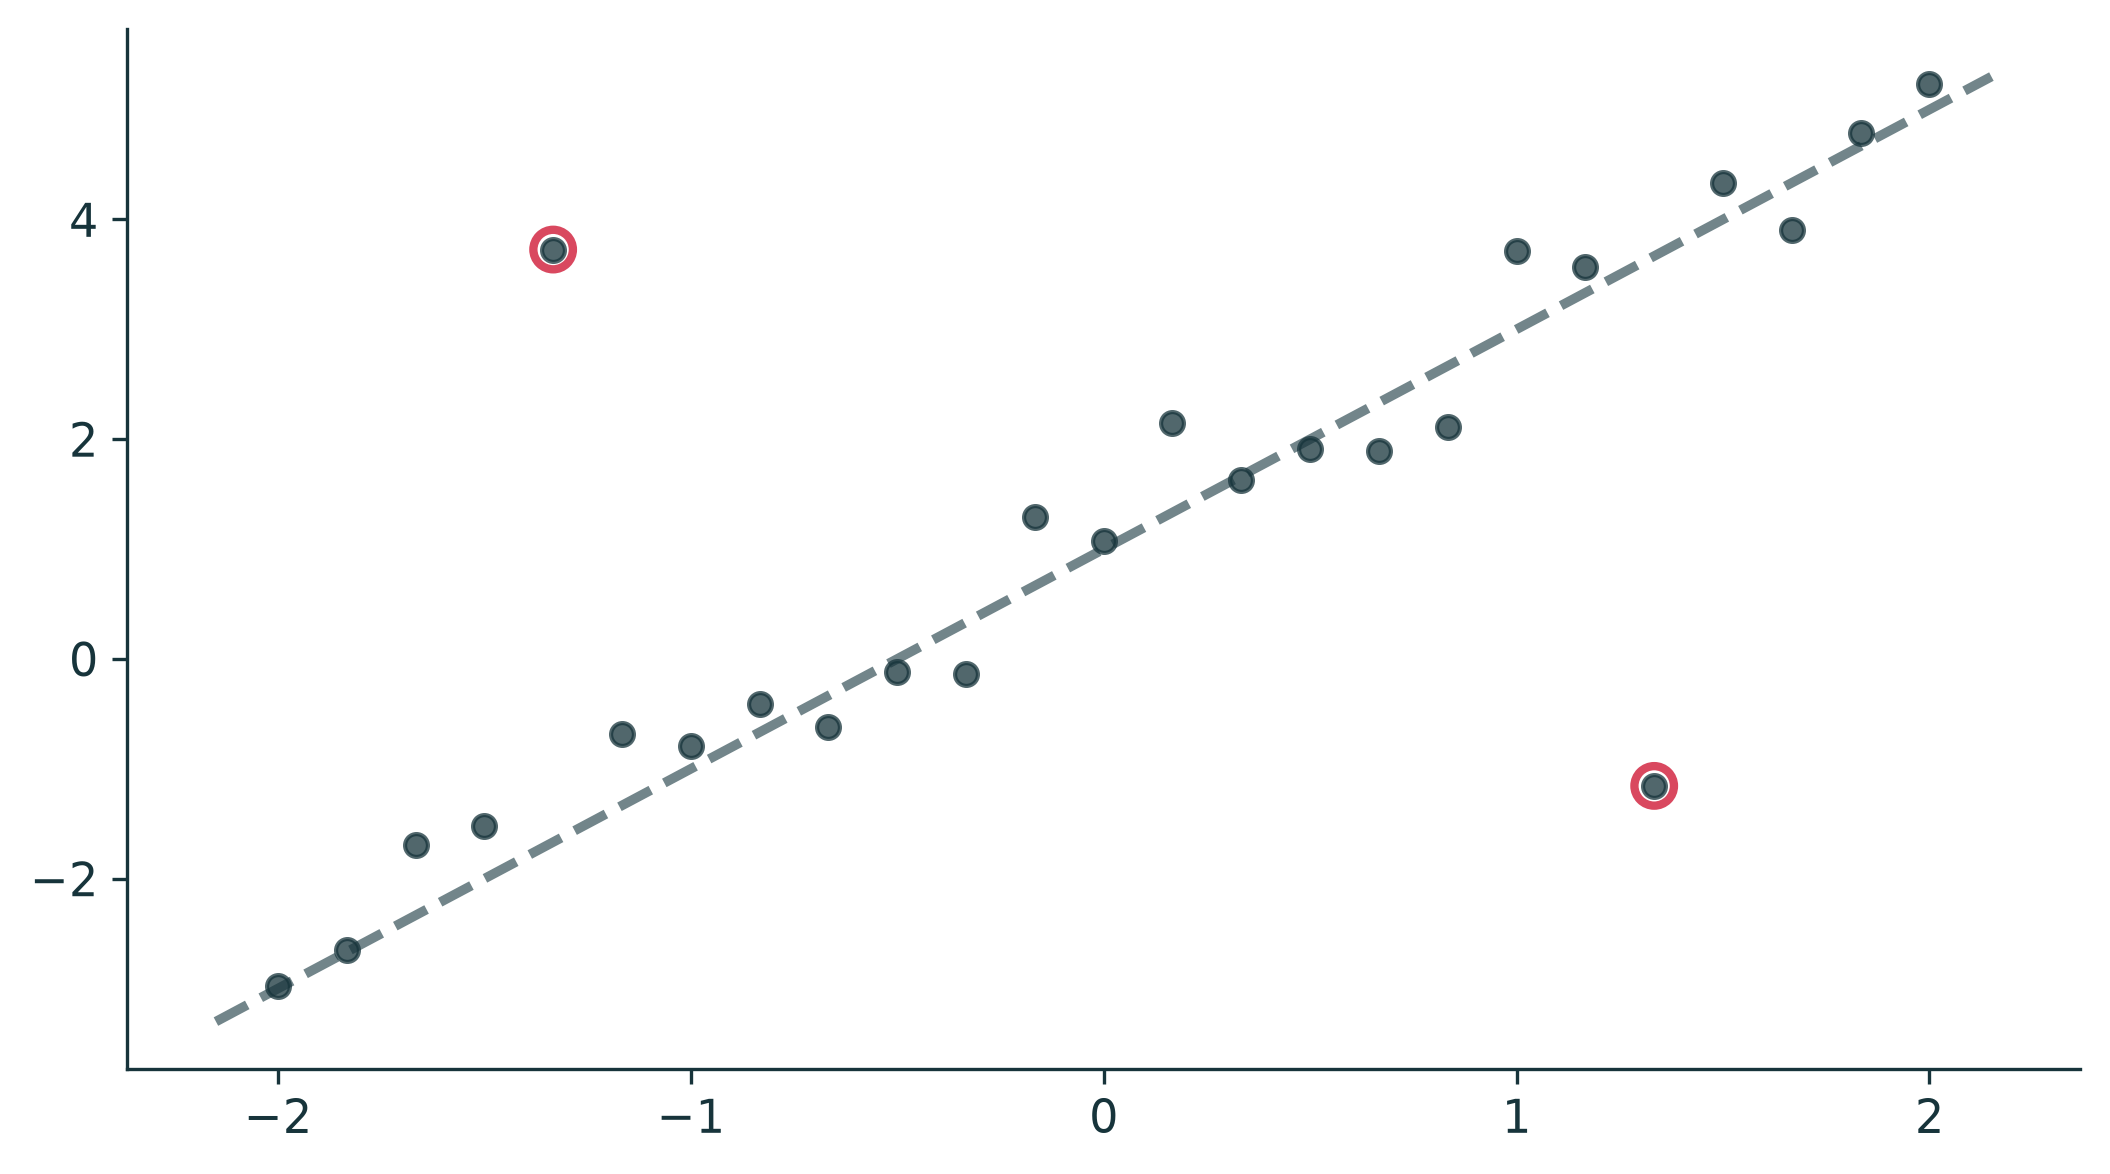

In [14]:
colors = {"Gaussian": BLUE, "Laplace": ORANGE, "Student-t": TEAL}
x_line = torch.linspace(-2.15, 2.15, 300)

fig, ax = plt.subplots(figsize=(8.4, 4.5))
ax.scatter(x, y, s=30, color=INK, alpha=0.75, label="observed data", zorder=3)
ax.scatter(x[outlier_index], y[outlier_index], s=90, facecolor="none",
           edgecolor=RED, linewidth=2, label="outliers", zorder=4)
ax.plot(x_line, true_intercept + true_slope * x_line, color=MUTED,
        linestyle="--", label="true line")

In [15]:
for model_name, theta_hat in fits.items():
    prediction = theta_hat[0] + theta_hat[1] * x_line
    ax.plot(x_line, prediction, color=colors[model_name], label=model_name)

ax.set(xlabel="input x", ylabel="target y",
       title="Gaussian bends toward the outliers; heavy-tailed fits resist them")
ax.grid(alpha=0.25)
ax.legend(ncols=3, loc="upper center")
plt.tight_layout()
plt.show()

<Figure size 960x720 with 0 Axes>

## 5. Which observations control each fit?

For every fitted model, compute each point's penalty relative to a perfect residual of zero. A tall bar
means that observation has a large effect on the summed training objective.

In [16]:
point_penalties = {}
for model_name, theta_hat in fits.items():
    mean = theta_hat[0] + theta_hat[1] * x
    model = observation_model(model_name, mean)
    perfect = observation_model(model_name, y)
    point_penalties[model_name] = -model.log_prob(y) + perfect.log_prob(y)

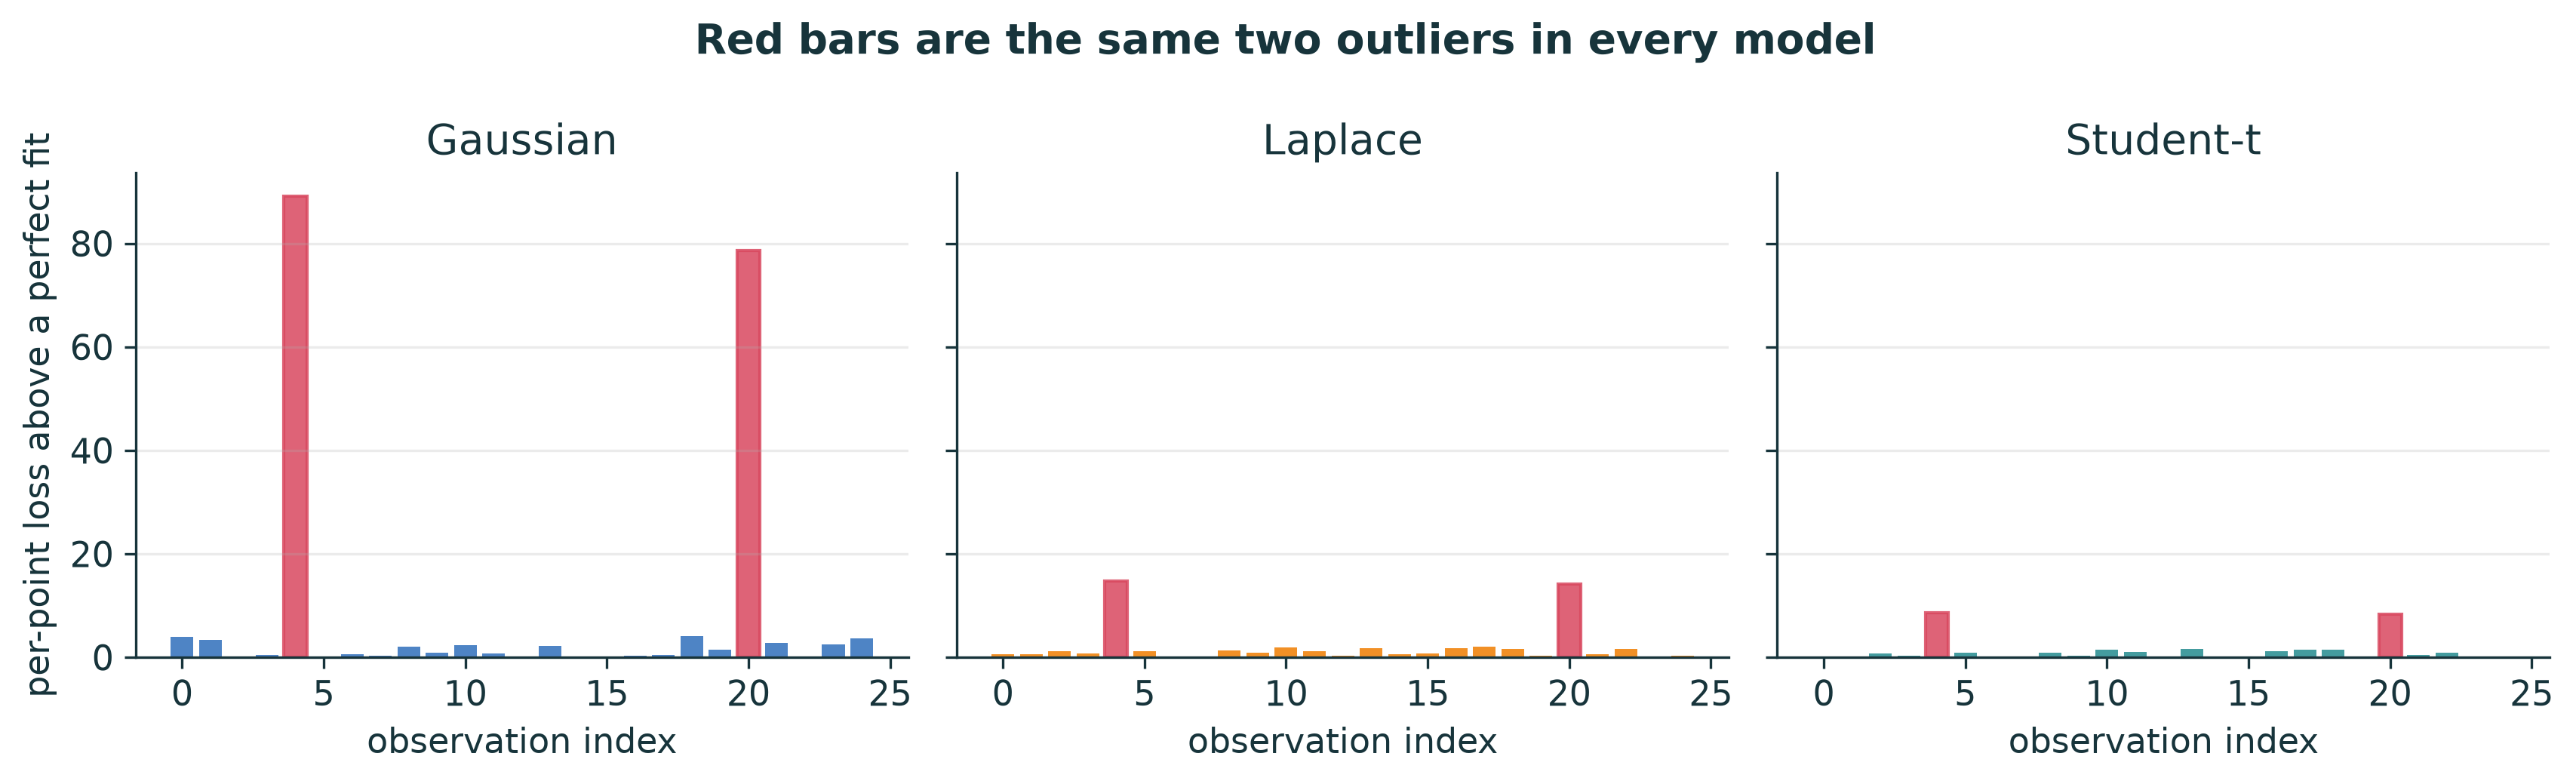

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5), sharey=True)
for ax, model_name in zip(axes, ["Gaussian", "Laplace", "Student-t"]):
    bars = ax.bar(torch.arange(x.numel()), point_penalties[model_name],
                  color=colors[model_name], alpha=0.85)
    for index in outlier_index.tolist():
        bars[index].set_color(RED)
    ax.set(title=model_name, xlabel="observation index")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("per-point loss above a perfect fit")
fig.suptitle("Red bars are the same two outliers in every model", fontweight="bold")
fig.tight_layout()
plt.show()

## 6. A practical decision rule

| Observation model | Equivalent loss | When it is a useful starting point |
|---|---|---|
| Gaussian | MSE | residuals are light-tailed; large errors really should be punished strongly |
| Laplace | MAE | occasional large errors are expected; a constant-magnitude correction is desirable |
| Student-t | heavy-tailed NLL | gross outliers may occur and should be discounted smoothly rather than discarded |

**Takeaway.** A loss function is not merely a numerical preference. It states what kinds of measurement
errors we believe the data-generating process can produce. Inspect residuals, compare fits, and validate on
held-out data; robustness is an assumption to test, not an automatic guarantee.

## Appendix A · Deck audit: the exact 12-point teaching case

This appendix is deliberately separate from the main $y=1+2x$ experiment above. It reproduces the
small case carried through the Lecture 1 deck: ten typical observations and two declared outliers.

**Evidence contract: SYNTHETIC · COMPUTED.** The coordinates are constructed for hand inspection.
The coefficients below are deterministic consequences of those displayed coordinates and likelihoods;
they are not measured performance, model output, or a benchmark result.

- Gaussian uses the closed-form least-squares solution.
- Laplace uses the exact least-absolute-deviation optimum found by enumerating all data-pair lines. In
  a two-parameter line fit, a finite LAD optimum exists at a vertex where at least two residuals are zero.
- Student-$t$ uses deterministic full-batch L-BFGS on the displayed negative log-likelihood.

The assertions make the notebook fail if any three-decimal coefficient printed in the deck drifts.

In [18]:
deck_inliers = torch.tensor([
    [-3.0, -2.8], [-2.4, -2.2], [-1.8, -1.9], [-1.2, -0.9], [-0.6, -0.5],
    [ 0.0,  0.2], [ 0.7,  0.8], [ 1.4,  1.2], [ 2.0,  2.2], [ 2.6,  2.4],
])
deck_outliers = torch.tensor([[-2.2, 3.3], [2.2, -3.2]])
deck_data = torch.cat([deck_inliers, deck_outliers])
deck_x, deck_y = deck_data[:, 0], deck_data[:, 1]


def ols_fit(x, y):
    design = torch.column_stack((torch.ones_like(x), x))
    return torch.linalg.lstsq(design, y).solution


def exact_lad_fit(x, y):
    candidates = []
    for i in range(x.numel()):
        for j in range(i + 1, x.numel()):
            if x[i] == x[j]:
                continue
            slope = (y[j] - y[i]) / (x[j] - x[i])
            intercept = y[i] - slope * x[i]
            loss = (y - (intercept + slope * x)).abs().sum()
            candidates.append((loss.item(), intercept.item(), slope.item()))
    _, intercept, slope = min(candidates)
    return torch.tensor([intercept, slope])


def student_t_fit(x, y, *, nu, scale):
    theta = torch.zeros(2, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [theta], lr=0.5, max_iter=500,
        tolerance_grad=1e-12, tolerance_change=1e-15,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        mean = theta[0] + theta[1] * x
        loss = -D.StudentT(nu, mean, scale).log_prob(y).sum()
        loss.backward()
        return loss

    optimizer.step(closure)
    return theta.detach()

In [19]:
deck_typical_fit = ols_fit(deck_inliers[:, 0], deck_inliers[:, 1])
deck_gaussian_fit = ols_fit(deck_x, deck_y)
deck_laplace_fit = exact_lad_fit(deck_x, deck_y)
deck_student_fits = {
    (1.0, 1.0): student_t_fit(deck_x, deck_y, nu=1.0, scale=1.0),
    (3.0, 0.5): student_t_fit(deck_x, deck_y, nu=3.0, scale=0.5),
    (3.0, 1.0): student_t_fit(deck_x, deck_y, nu=3.0, scale=1.0),
    (3.0, 1.5): student_t_fit(deck_x, deck_y, nu=3.0, scale=1.5),
    (30.0, 1.0): student_t_fit(deck_x, deck_y, nu=30.0, scale=1.0),
}


def rounded_pair(theta):
    return tuple(float(f"{value.item():.3f}") for value in theta)


expected = {
    "typical OLS": (0.070, 0.955),
    "Gaussian": (-0.040, 0.397),
    "Laplace": (0.044, 0.906),
    "Student-t nu=1, s=1": (0.064, 0.928),
    "Student-t nu=3, s=0.5": (0.065, 0.934),
    "Student-t nu=3, s=1": (0.053, 0.882),
    "Student-t nu=3, s=1.5": (0.036, 0.807),
    "Student-t nu=30, s=1": (-0.014, 0.581),
}
observed = {
    "typical OLS": rounded_pair(deck_typical_fit),
    "Gaussian": rounded_pair(deck_gaussian_fit),
    "Laplace": rounded_pair(deck_laplace_fit),
    "Student-t nu=1, s=1": rounded_pair(deck_student_fits[(1.0, 1.0)]),
    "Student-t nu=3, s=0.5": rounded_pair(deck_student_fits[(3.0, 0.5)]),
    "Student-t nu=3, s=1": rounded_pair(deck_student_fits[(3.0, 1.0)]),
    "Student-t nu=3, s=1.5": rounded_pair(deck_student_fits[(3.0, 1.5)]),
    "Student-t nu=30, s=1": rounded_pair(deck_student_fits[(30.0, 1.0)]),
}

print("SYNTHETIC · COMPUTED · exact Lecture 1 deck case")
print("model                         fitted (theta_0, theta_1)")
for name, pair in observed.items():
    print(f"{name:29s} ({pair[0]:.3f}, {pair[1]:.3f})")

assert observed == expected, (observed, expected)
print("\nAll deck coefficient assertions passed.")

SYNTHETIC · COMPUTED · exact Lecture 1 deck case
model                         fitted (theta_0, theta_1)
typical OLS                   (0.070, 0.955)
Gaussian                      (-0.040, 0.397)
Laplace                       (0.044, 0.906)
Student-t nu=1, s=1           (0.064, 0.928)
Student-t nu=3, s=0.5         (0.065, 0.934)
Student-t nu=3, s=1           (0.053, 0.882)
Student-t nu=3, s=1.5         (0.036, 0.807)
Student-t nu=30, s=1          (-0.014, 0.581)

All deck coefficient assertions passed.


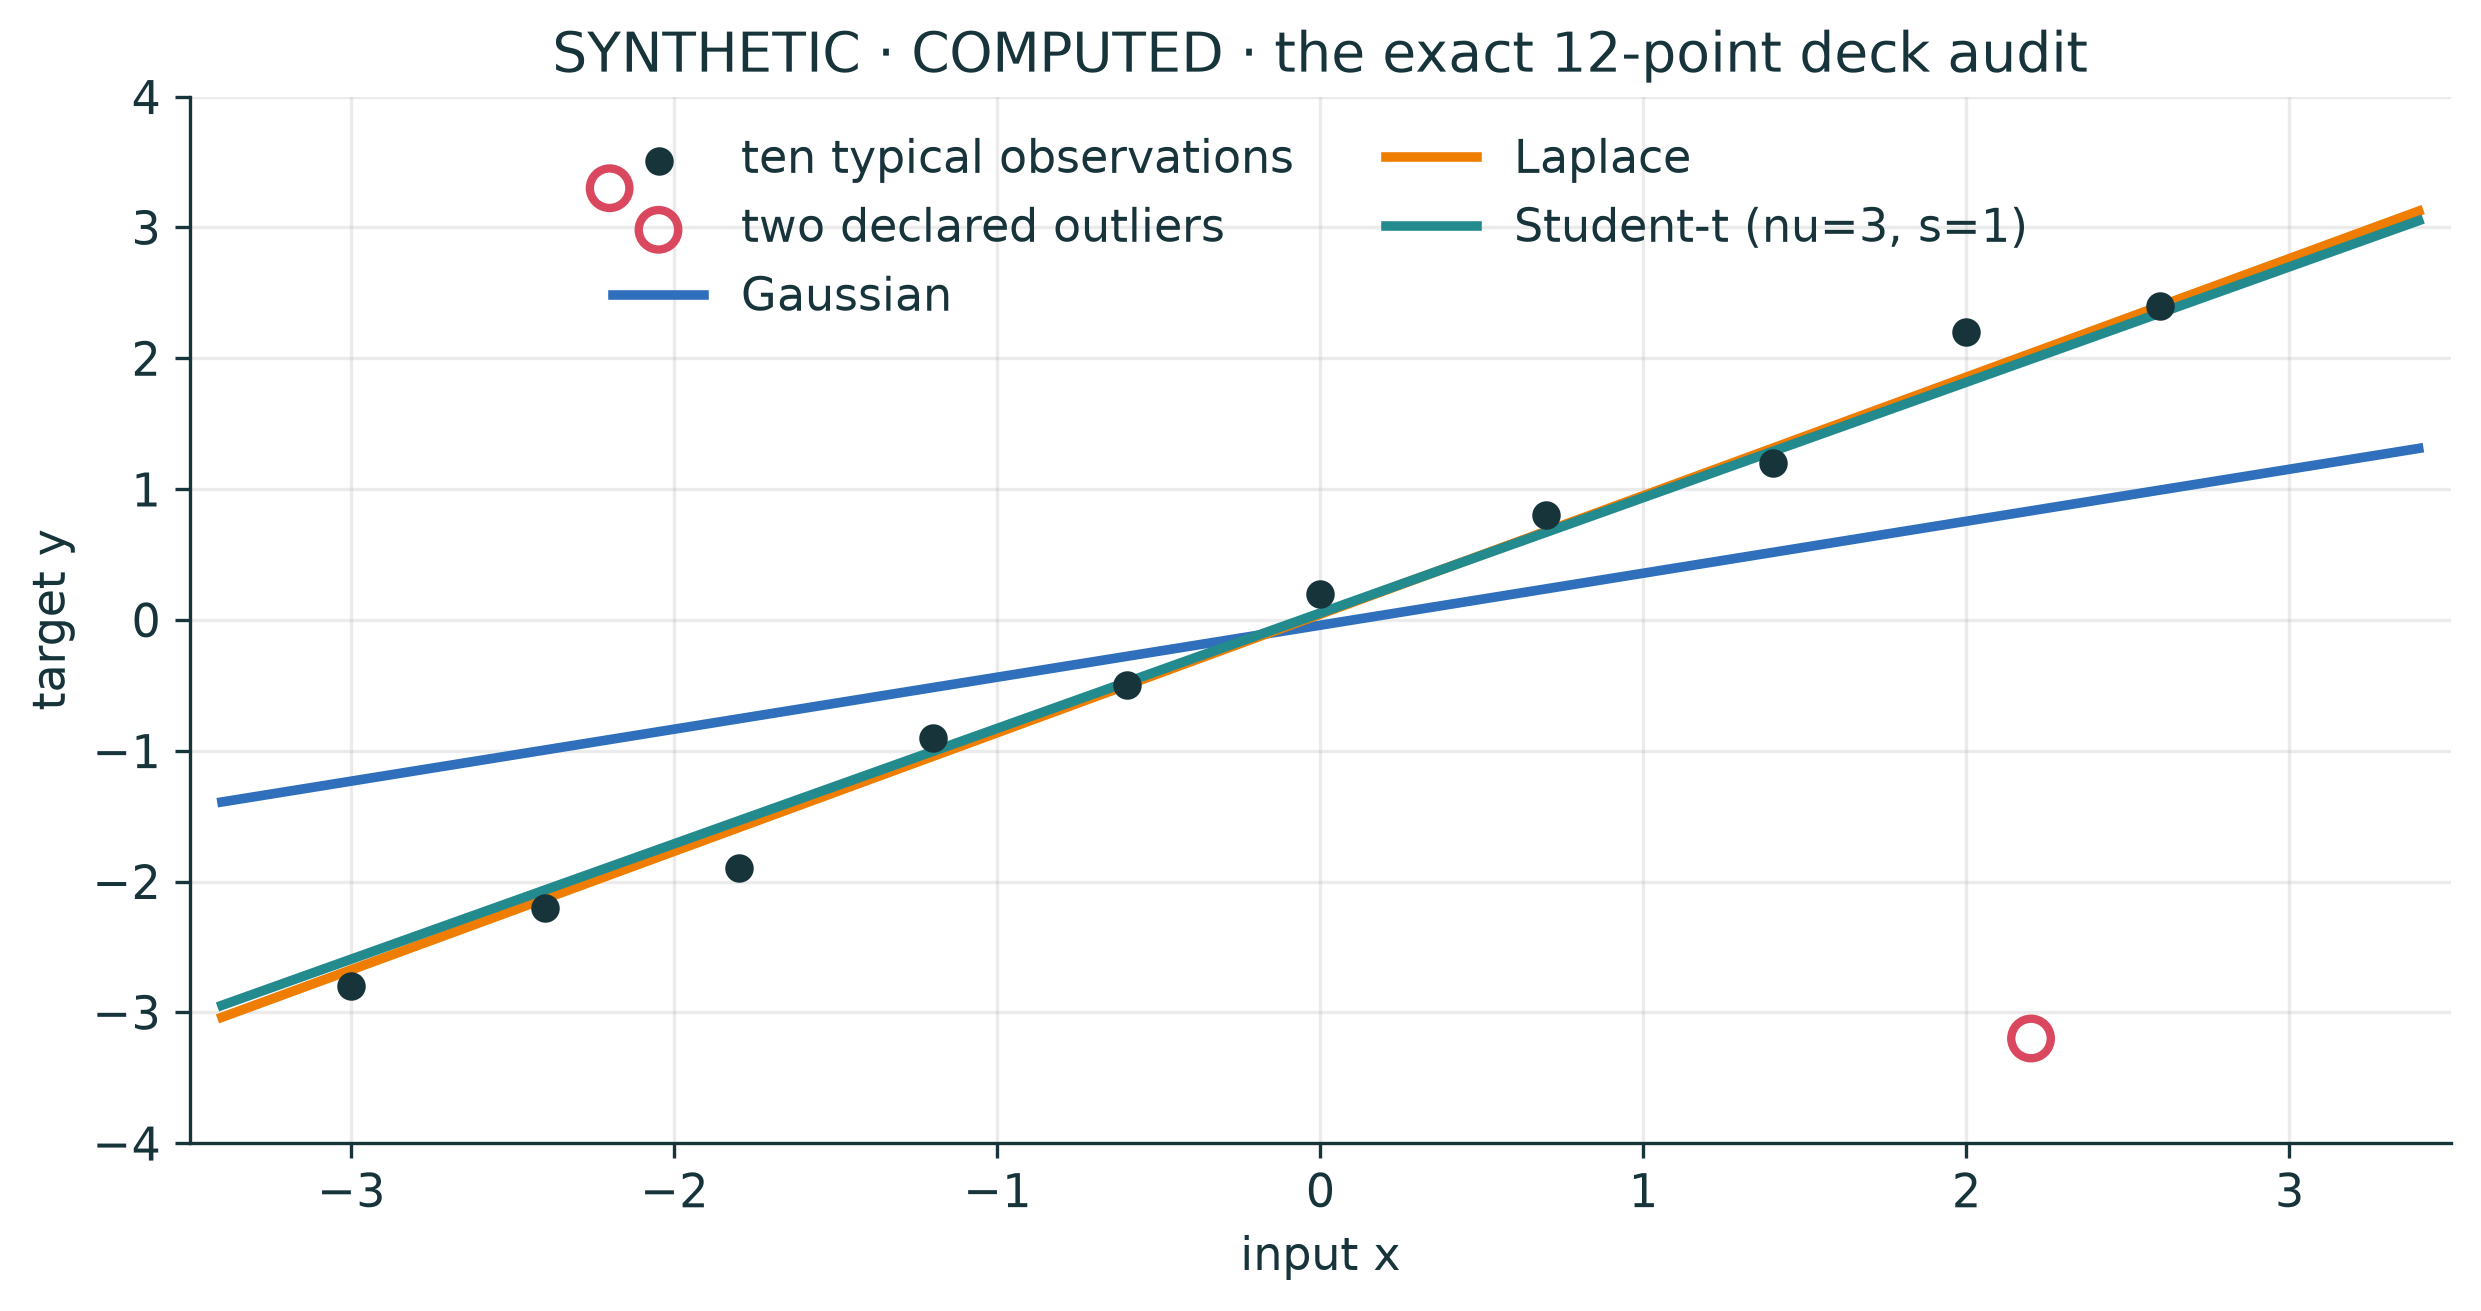

In [20]:
deck_line_x = torch.linspace(-3.4, 3.4, 300)
fig, ax = plt.subplots(figsize=(8.4, 4.5))
ax.scatter(deck_inliers[:, 0], deck_inliers[:, 1], s=34, color=INK,
           label="ten typical observations", zorder=3)
ax.scatter(deck_outliers[:, 0], deck_outliers[:, 1], s=90, facecolor="none",
           edgecolor=RED, linewidth=2, label="two declared outliers", zorder=4)
for name, theta, color in [
    ("Gaussian", deck_gaussian_fit, BLUE),
    ("Laplace", deck_laplace_fit, ORANGE),
    ("Student-t (nu=3, s=1)", deck_student_fits[(3.0, 1.0)], TEAL),
]:
    ax.plot(deck_line_x, theta[0] + theta[1] * deck_line_x, color=color, label=name)

ax.set(
    title="SYNTHETIC · COMPUTED · the exact 12-point deck audit",
    xlabel="input x", ylabel="target y", xlim=(-3.5, 3.5), ylim=(-4, 4),
)
ax.grid(alpha=0.25)
ax.legend(ncols=2, loc="upper center")
plt.tight_layout()
plt.show()